In [6]:
# uciml/red-wine-quality-cortez-et-al-2009
file = 'winequality-red.csv'

import pandas as pd

df = pd.read_csv(file)

df.sample(5)
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


# EDA анализ

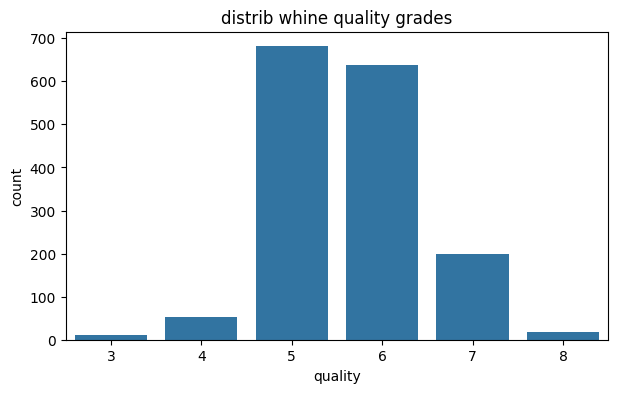

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
# 1 --- строим распределение качества
plt.figure(figsize=(7, 4))
sns.countplot(x='quality', data=df)
plt.title("distrib whine quality grades")
plt.show()

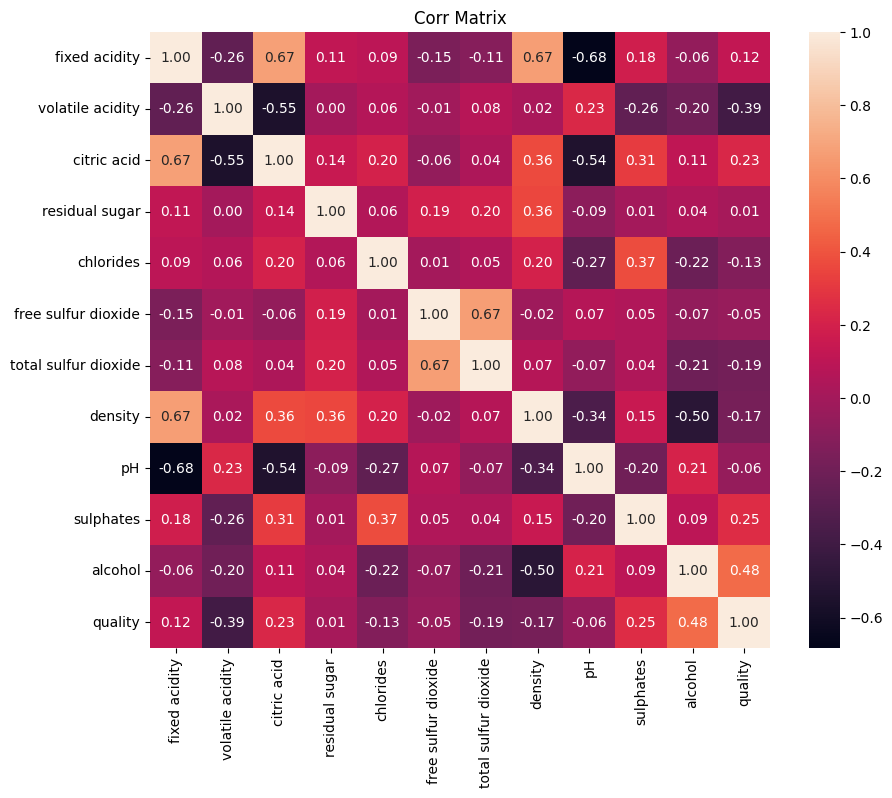

In [23]:
# --- 2 corr matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f")
plt.title('Corr Matrix')
plt.show()

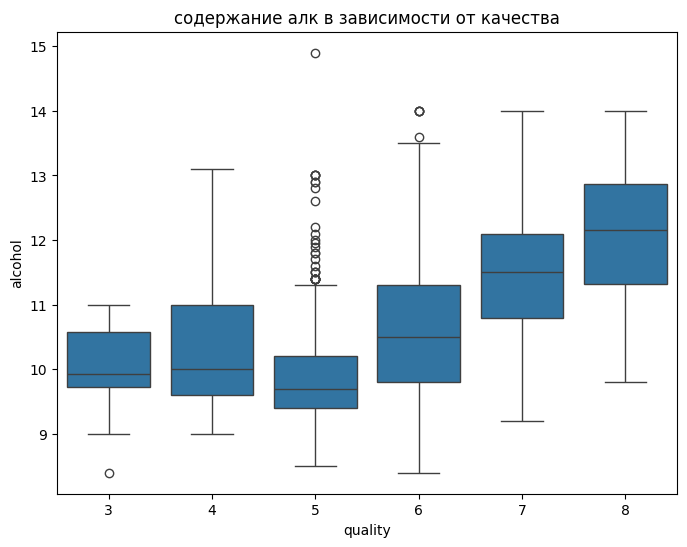

In [24]:
# 3 --- Box Plot (alc)
plt.figure(figsize=(8, 6))
sns.boxplot(x='quality', y='alcohol', data=df)
plt.title('содержание алк в зависимости от качества')
plt.show()

In [26]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score, confusion_matrix
import pandas as pd
import numpy as np

df['is_good'] = np.where(df['quality'] >= 7, 1, 0)

print(df['is_good'].value_counts(normalize=True))

X = df.drop(['quality', 'is_good'], axis=1) 
y = df['is_good']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y # Stratify=y важен при дисбалансе!
)

rf_model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"\nF1-Score {f1:.4f}")
print("\nМатрица Ошибок:")
print(cm)


is_good
0    0.86429
1    0.13571
Name: proportion, dtype: float64

F1-Score 0.6796

Матрица Ошибок:
[[412   3]
 [ 30  35]]
